Dataset shape: (569, 30)
Benign samples: 357
Malignant samples: 212
Epoch 001 | Train Accuracy: 93.41% | Test Accuracy: 88.60%
Epoch 002 | Train Accuracy: 96.26% | Test Accuracy: 92.11%
Epoch 003 | Train Accuracy: 97.36% | Test Accuracy: 94.74%
Epoch 004 | Train Accuracy: 97.58% | Test Accuracy: 95.61%
Epoch 005 | Train Accuracy: 96.70% | Test Accuracy: 93.86%
Epoch 006 | Train Accuracy: 98.02% | Test Accuracy: 97.37%
Epoch 007 | Train Accuracy: 97.36% | Test Accuracy: 95.61%
Epoch 008 | Train Accuracy: 97.80% | Test Accuracy: 96.49%
Epoch 009 | Train Accuracy: 97.80% | Test Accuracy: 95.61%
Epoch 010 | Train Accuracy: 96.04% | Test Accuracy: 95.61%
Epoch 011 | Train Accuracy: 98.02% | Test Accuracy: 99.12%
Epoch 012 | Train Accuracy: 96.92% | Test Accuracy: 92.98%
Epoch 013 | Train Accuracy: 98.24% | Test Accuracy: 94.74%
Epoch 014 | Train Accuracy: 98.68% | Test Accuracy: 96.49%
Epoch 015 | Train Accuracy: 98.02% | Test Accuracy: 93.86%
Epoch 016 | Train Accuracy: 94.95% | Test Accur

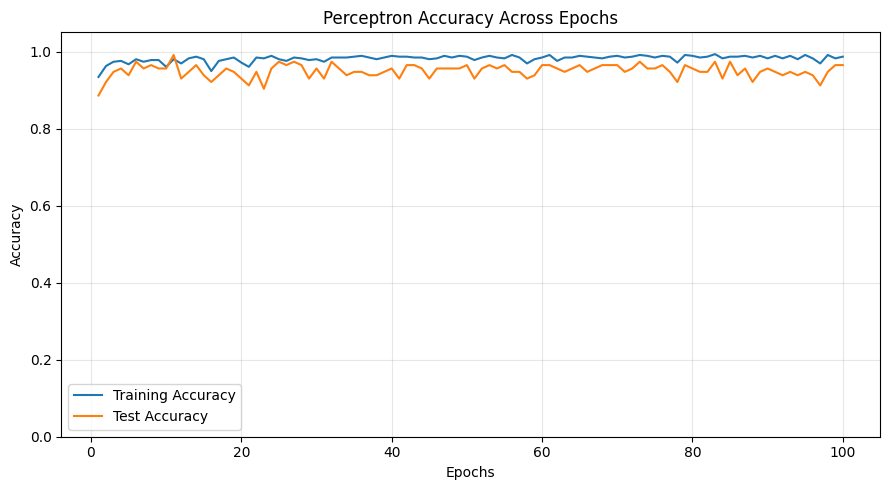

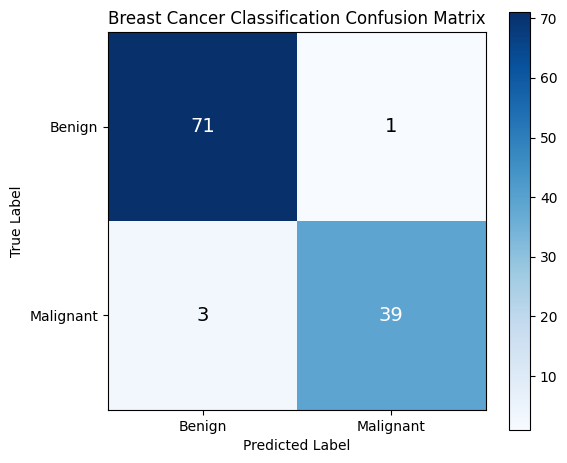

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# ==========================================
# LOAD DATA
# ==========================================

file_path = "/content/wdbc.data"

# WDBC format:
# Column 0 = ID
# Column 1 = Diagnosis: B (Benign) or M (Malignant)
# Columns 2+ = numerical features
data = np.genfromtxt(file_path, delimiter=",", dtype=str)

X = data[:, 2:].astype(float)
y = np.where(data[:, 1] == "M", 1, 0)

print("Dataset shape:", X.shape)
print("Benign samples:", np.sum(y == 0))
print("Malignant samples:", np.sum(y == 1))


# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Normalize using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Avoid division by zero
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


# ==========================================
# BINARY PERCEPTRON FROM SCRATCH
# ==========================================

class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = 0.0
        self.train_accuracies = []
        self.test_accuracies = []

    def decision_function(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def fit(self, X_train, y_train, X_test, y_test):
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0.0

        rng = np.random.default_rng(42)

        for epoch in range(self.n_epochs):
            indices = rng.permutation(len(X_train))

            for index in indices:
                xi = X_train[index]
                target = y_train[index]

                prediction = self.predict(xi)
                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

            train_accuracy = self.accuracy(X_train, y_train)
            test_accuracy = self.accuracy(X_test, y_test)

            self.train_accuracies.append(train_accuracy)
            self.test_accuracies.append(test_accuracy)

            print(
                f"Epoch {epoch + 1:03d} | "
                f"Train Accuracy: {train_accuracy:.2%} | "
                f"Test Accuracy: {test_accuracy:.2%}"
            )


# ==========================================
# TRAIN MODEL
# ==========================================

perceptron = Perceptron(learning_rate=0.01, n_epochs=100)

perceptron.fit(
    X_train,
    y_train,
    X_test,
    y_test
)


# ==========================================
# FINAL RESULTS
# ==========================================

train_predictions = perceptron.predict(X_train)
test_predictions = perceptron.predict(X_test)

final_train_accuracy = np.mean(train_predictions == y_train)
final_test_accuracy = np.mean(test_predictions == y_test)

print("\nFinal Results")
print(f"Training Accuracy: {final_train_accuracy:.2%}")
print(f"Test Accuracy: {final_test_accuracy:.2%}")


# ==========================================
# CONFUSION MATRIX
# ==========================================

true_negative = np.sum((y_test == 0) & (test_predictions == 0))
false_positive = np.sum((y_test == 0) & (test_predictions == 1))
false_negative = np.sum((y_test == 1) & (test_predictions == 0))
true_positive = np.sum((y_test == 1) & (test_predictions == 1))

confusion_matrix = np.array([
    [true_negative, false_positive],
    [false_negative, true_positive]
])

print("\nConfusion Matrix")
print(confusion_matrix)


# ==========================================
# PLOT ACCURACY
# ==========================================

epochs = range(1, perceptron.n_epochs + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, perceptron.train_accuracies, label="Training Accuracy")
plt.plot(epochs, perceptron.test_accuracies, label="Test Accuracy")

plt.title("Perceptron Accuracy Across Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# PLOT CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix, cmap="Blues")

plt.title("Breast Cancer Classification Confusion Matrix")
plt.colorbar()

labels = ["Benign", "Malignant"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion_matrix[row, column],
            ha="center",
            va="center",
            color="white" if confusion_matrix[row, column] > confusion_matrix.max() / 2 else "black",
            fontsize=14
        )

plt.tight_layout()
plt.show()